In [1]:
import gc
import tensorflow as tf


tf.keras.backend.clear_session()
gc.collect()

print("Memory cleared.")

2026-05-23 19:01:27.269929: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Memory cleared.


In [2]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

In [4]:
PROJECT_ROOT = "/home/jovyan"

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 5e-6

KEEP_CLASSES = ["akiec", "bcc", "bkl", "mel", "nv"]
NUM_CLASSES = len(KEEP_CLASSES)

print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("MODELS_DIR:", MODELS_DIR)

DATA_DIR: /home/jovyan/data
RESULTS_DIR: /home/jovyan/results
MODELS_DIR: /home/jovyan/models


In [5]:
metadata_path = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)

image_dirs = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2")
]

image_path_dict = {}

for image_dir in image_dirs:
    for filename in os.listdir(image_dir):
        if filename.endswith(".jpg"):
            image_id = filename.replace(".jpg", "")
            image_path_dict[image_id] = os.path.join(image_dir, filename)

df["image_path"] = df["image_id"].map(image_path_dict)

print("Total rows before filtering:", len(df))
print("Missing image paths:", df["image_path"].isna().sum())

df = df.dropna(subset=["image_path"]).copy()

Total rows before filtering: 10015
Missing image paths: 0


In [6]:
df_5 = df[df["dx"].isin(KEEP_CLASSES)].copy()

print("Rows after filtering:", len(df_5))
print("\nClass distribution:")
print(df_5["dx"].value_counts())

Rows after filtering: 9758

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
Name: count, dtype: int64


In [7]:
class_to_label = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "mel": 3,
    "nv": 4
}

label_to_class = {
    0: "akiec",
    1: "bcc",
    2: "bkl",
    3: "mel",
    4: "nv"
}

df_5["label"] = df_5["dx"].map(class_to_label)

print(df_5[["image_id", "dx", "label", "image_path"]].head())
print("\nLabel distribution:")
print(df_5["label"].value_counts().sort_index())

       image_id   dx  label                                         image_path
0  ISIC_0027419  bkl      2  /home/jovyan/data/HAM10000_images_part_1/ISIC_...
1  ISIC_0025030  bkl      2  /home/jovyan/data/HAM10000_images_part_1/ISIC_...
2  ISIC_0026769  bkl      2  /home/jovyan/data/HAM10000_images_part_1/ISIC_...
3  ISIC_0025661  bkl      2  /home/jovyan/data/HAM10000_images_part_1/ISIC_...
4  ISIC_0031633  bkl      2  /home/jovyan/data/HAM10000_images_part_2/ISIC_...

Label distribution:
label
0     327
1     514
2    1099
3    1113
4    6705
Name: count, dtype: int64


In [8]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [9]:
train_df = pd.read_csv(os.path.join(RESULTS_DIR, "train_split_5class.csv"))
val_df = pd.read_csv(os.path.join(RESULTS_DIR, "val_split_5class.csv"))
test_df = pd.read_csv(os.path.join(RESULTS_DIR, "test_split_5class.csv"))

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["dx"].value_counts())

print("\nValidation distribution:")
print(val_df["dx"].value_counts())

print("\nTest distribution:")
print(test_df["dx"].value_counts())

Train: 7025
Validation: 781
Test: 1952

Train distribution:
dx
nv       4827
mel       801
bkl       791
bcc       370
akiec     236
Name: count, dtype: int64

Validation distribution:
dx
nv       537
mel       89
bkl       88
bcc       41
akiec     26
Name: count, dtype: int64

Test distribution:
dx
nv       1341
mel       223
bkl       220
bcc       103
akiec      65
Name: count, dtype: int64


In [10]:
classes = np.sort(train_df["label"].unique())

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(c): min(float(w), 3.0)
    for c, w in zip(classes, class_weights_array)

}

print("Capped class weights:")
for k, v in class_weights.items():
    print(f"{label_to_class[k]} ({k}): {v:.4f}")

Capped class weights:
akiec (0): 3.0000
bcc (1): 3.0000
bkl (2): 1.7762
mel (3): 1.7541
nv (4): 0.2911


In [11]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_df["label"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label"].values)
)

train_ds = (
    train_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

I0000 00:00:1779562902.119565   20297 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11981 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:2a:00.0, compute capability: 8.6


Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


2026-05-23 19:01:43.918797: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,147,333 (92.11 MB)

 Trainable params: 15,009,029 (57.25 MB)

 Non-trainable params: 9,138,304 (34.86 MB)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, "resnet50_5class_best.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

model.save(os.path.join(MODELS_DIR, "resnet50_5class_run1.keras"))
print("5-class ResNet model saved.")

Epoch 1/15


2026-05-23 19:02:03.303582: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


440/440 ━━━━━━━━━━━━━━━━━━━━ 86s 150ms/step - accuracy: 0.3226 - loss: 1.6188 - val_accuracy: 0.1383 - val_loss: 2.3406
Epoch 2/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 63s 141ms/step - accuracy: 0.3862 - loss: 1.4651 - val_accuracy: 0.4609 - val_loss: 1.7752
Epoch 3/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 64s 142ms/step - accuracy: 0.4037 - loss: 1.4306 - val_accuracy: 0.3803 - val_loss: 1.9777
Epoch 4/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 64s 142ms/step - accuracy: 0.4172 - loss: 1.4029 - val_accuracy: 0.5800 - val_loss: 1.3941
Epoch 5/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 63s 141ms/step - accuracy: 0.4336 - loss: 1.3297 - val_accuracy: 0.2586 - val_loss: 2.3737
Epoch 6/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 62s 138ms/step - accuracy: 0.4440 - loss: 1.3401 - val_accuracy: 0.2343 - val_loss: 2.5515
Epoch 7/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 63s 139ms/step - accuracy: 0.4511 - loss: 1.2870 - val_accuracy: 0.1076 - val_loss: 2.9013
Epoch 8/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 63s 140ms/step - accuracy: 0.4659 - loss: 1.3199 - val

In [14]:
model.save(os.path.join(MODELS_DIR, "resnet50_5class2.keras")
)
y_true = test_df["label"].values

y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

labels = [label_to_class[i] for i in range(NUM_CLASSES)]

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("Confusion matrix:")
display(cm_df)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step
Confusion matrix:


,akiec,bcc,bkl,mel,nv
akiec,16,17,1,14,17
bcc,6,43,3,11,40
bkl,15,19,8,59,119
mel,12,13,7,97,94
nv,18,46,12,165,1100



Classification report:
              precision    recall  f1-score   support

       akiec     0.2388    0.2462    0.2424        65
         bcc     0.3116    0.4175    0.3568       103
         bkl     0.2581    0.0364    0.0637       220
         mel     0.2803    0.4350    0.3409       223
          nv     0.8029    0.8203    0.8115      1341

    accuracy                         0.6475      1952
   macro avg     0.3783    0.3911    0.3631      1952
weighted avg     0.6371    0.6475    0.6305      1952



In [15]:
metrics = []

for i, class_name in label_to_class.items():
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    metrics.append({
        "Class": class_name,
        "Sensitivity/Recall": sensitivity,
        "Specificity": specificity,
        "Support": np.sum(cm[i, :])
    })

metrics_df = pd.DataFrame(metrics)

balanced_accuracy = metrics_df["Sensitivity/Recall"].mean()

display(metrics_df)

print("Balanced accuracy:", round(balanced_accuracy, 4))

,Class,Sensitivity/Recall,Specificity,Support
0,akiec,0.246154,0.972973,65
1,bcc,0.417476,0.948621,103
2,bkl,0.036364,0.986721,220
3,mel,0.434978,0.855986,223
4,nv,0.820283,0.558101,1341


Balanced accuracy: 0.3911


In [16]:
mel_metrics = metrics_df[metrics_df["Class"] == "mel"]
display(mel_metrics)

,Class,Sensitivity/Recall,Specificity,Support
3,mel,0.434978,0.855986,223


In [17]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

7025
781
1952
label
4    4827
3     801
2     791
1     370
0     236
Name: count, dtype: int64
label
4    1341
3     223
2     220
1     103
0      65
Name: count, dtype: int64


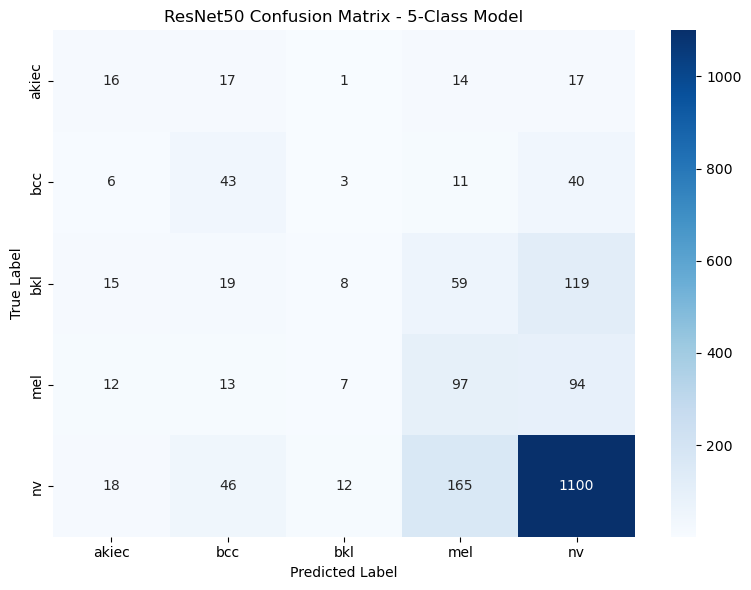

Saved to: /home/jovyan/results/resnet50_5class_confusion_matrix.png


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

class_names = ["akiec", "bcc", "bkl", "mel", "nv"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix - 5-Class Model")

plt.tight_layout()

save_path = os.path.join(RESULTS_DIR, "resnet50_5class_confusion_matrix.png")
plt.savefig(save_path, dpi=300)

plt.show()

print("Saved to:", save_path)

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Folder for ResNet 3.0 results
output_dir = "resnet50_5class_3_0_results"
os.makedirs(output_dir, exist_ok=True)

print("Results folder:", output_dir)

Results folder: resnet50_5class_3_0_results


In [20]:
history_df = pd.DataFrame(history.history)

history_df["generalization_gap"] = (
    history_df["accuracy"] - history_df["val_accuracy"]
)

history_df["val_accuracy_change"] = history_df["val_accuracy"].diff().abs()
history_df["val_loss_change"] = history_df["val_loss"].diff().abs()

save_path = os.path.join(output_dir, "training_history.csv")
history_df.to_csv(save_path, index=False)

print("Saved training history to:", save_path)
print("Files in folder:", os.listdir(output_dir))

history_df

Saved training history to: resnet50_5class_3_0_results/training_history.csv
Files in folder: ['training_history.csv']


,accuracy,loss,val_accuracy,val_loss,generalization_gap,val_accuracy_change,val_loss_change
0,0.322562,1.618845,0.138284,2.340567,0.184278,NaN,NaN
1,0.386192,1.465130,0.460948,1.775156,-0.074755,0.322663,0.565411
2,0.403701,1.430585,0.380282,1.977719,0.023419,0.080666,0.202563
3,0.417224,1.402943,0.580026,1.394128,-0.162801,0.199744,0.583590
4,0.433594,1.329714,0.258643,2.373698,0.174952,0.321383,0.979569
5,0.443986,1.340098,0.234315,2.551540,0.209671,0.024328,0.177842
6,0.451103,1.286973,0.107554,2.901287,0.343549,0.126761,0.349747
7,0.465907,1.319914,0.521127,1.456571,-0.055219,0.413572,1.444717
8,0.472456,1.292180,0.572343,1.242422,-0.099888,0.051216,0.214149
9,0.475160,1.256392,0.414853,1.936268,0.060307,0.157490,0.693846


In [21]:
summary_metrics = {
    "Final Training Accuracy": history_df["accuracy"].iloc[-1],
    "Final Validation Accuracy": history_df["val_accuracy"].iloc[-1],
    "Final Training Loss": history_df["loss"].iloc[-1],
    "Final Validation Loss": history_df["val_loss"].iloc[-1],
    "Best Validation Accuracy": history_df["val_accuracy"].max(),
    "Best Validation Accuracy Epoch": history_df["val_accuracy"].idxmax() + 1,
    "Best Validation Loss": history_df["val_loss"].min(),
    "Best Validation Loss Epoch": history_df["val_loss"].idxmin() + 1,
    "Final Generalization Gap": history_df["generalization_gap"].iloc[-1],
    "Average Generalization Gap": history_df["generalization_gap"].mean(),
    "Validation Accuracy Instability": history_df["val_accuracy_change"].mean(),
    "Validation Loss Instability": history_df["val_loss_change"].mean(),
    "Validation Accuracy Std": history_df["val_accuracy"].std(),
    "Validation Loss Std": history_df["val_loss"].std()
}

summary_metrics_df = pd.DataFrame(
    summary_metrics.items(),
    columns=["Metric", "Value"]
)

save_path = os.path.join(output_dir, "training_summary_metrics.csv")
summary_metrics_df.to_csv(save_path, index=False)

print("Saved training summary metrics to:", save_path)

summary_metrics_df

Saved training summary metrics to: resnet50_5class_3_0_results/training_summary_metrics.csv


,Metric,Value
0,Final Training Accuracy,0.497082
1,Final Validation Accuracy,0.110115
2,Final Training Loss,1.203284
3,Final Validation Loss,5.803228
4,Best Validation Accuracy,0.629962
5,Best Validation Accuracy Epoch,12.000000
6,Best Validation Loss,1.210623
7,Best Validation Loss Epoch,12.000000
8,Final Generalization Gap,0.386967
9,Average Generalization Gap,0.082210


In [22]:
class_names = ["akiec", "bcc", "bkl", "mel", "nv"]

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

save_path = os.path.join(output_dir, "confusion_matrix.csv")
cm_df.to_csv(save_path)

print("Saved confusion matrix to:", save_path)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

save_path = os.path.join(output_dir, "classification_report.csv")
report_df.to_csv(save_path)

print("Saved classification report to:", save_path)

report_df

Saved confusion matrix to: resnet50_5class_3_0_results/confusion_matrix.csv
Saved classification report to: resnet50_5class_3_0_results/classification_report.csv


,precision,recall,f1-score,support
akiec,0.238806,0.246154,0.242424,65.000000
bcc,0.311594,0.417476,0.356846,103.000000
bkl,0.258065,0.036364,0.063745,220.000000
mel,0.280347,0.434978,0.340949,223.000000
nv,0.802920,0.820283,0.811509,1341.000000
accuracy,0.647541,0.647541,0.647541,0.647541
macro avg,0.378346,0.391051,0.363095,1952.000000
weighted avg,0.637102,0.647541,0.630534,1952.000000


In [23]:
mel_index = 3

# Basic totals
total = np.sum(cm)
correct = np.trace(cm)

test_accuracy = correct / total

# Class-wise support
support = np.sum(cm, axis=1)

# Class-wise recall
class_recall = np.diag(cm) / np.sum(cm, axis=1)

# Class-wise precision
class_precision = np.diag(cm) / np.sum(cm, axis=0)

# Avoid division problems if any class has zero predictions
class_precision = np.nan_to_num(class_precision, nan=0.0)

# Class-wise F1
class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall)
class_f1 = np.nan_to_num(class_f1, nan=0.0)

# Macro metrics
balanced_accuracy = np.mean(class_recall)
macro_precision = np.mean(class_precision)
macro_recall = np.mean(class_recall)
macro_f1 = np.mean(class_f1)

# Weighted metrics
weighted_precision = np.average(class_precision, weights=support)
weighted_recall = np.average(class_recall, weights=support)
weighted_f1 = np.average(class_f1, weights=support)

# Melanoma metrics
tp = cm[mel_index, mel_index]
fn = np.sum(cm[mel_index, :]) - tp
fp = np.sum(cm[:, mel_index]) - tp
tn = np.sum(cm) - (tp + fn + fp)

melanoma_recall = tp / (tp + fn)
melanoma_specificity = tn / (tn + fp)

final_metrics = {
    "Test Accuracy": test_accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted Precision": weighted_precision,
    "Weighted Recall": weighted_recall,
    "Weighted F1": weighted_f1,
    "Melanoma Recall": melanoma_recall,
    "Melanoma Specificity": melanoma_specificity
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Value"]
)

save_path = os.path.join(output_dir, "final_test_metrics.csv")
final_metrics_df.to_csv(save_path, index=False)

print("Saved final test metrics to:", save_path)

final_metrics_df

Saved final test metrics to: resnet50_5class_3_0_results/final_test_metrics.csv


,Metric,Value
0,Test Accuracy,0.647541
1,Balanced Accuracy,0.391051
2,Macro Precision,0.378346
3,Macro Recall,0.391051
4,Macro F1,0.363095
5,Weighted Precision,0.637102
6,Weighted Recall,0.647541
7,Weighted F1,0.630534
8,Melanoma Recall,0.434978
9,Melanoma Specificity,0.855986


In [24]:
class_report_from_cm = pd.DataFrame({
    "precision": class_precision,
    "recall": class_recall,
    "f1-score": class_f1,
    "support": support
}, index=class_names)

# Add averages
accuracy_row = pd.DataFrame({
    "precision": [test_accuracy],
    "recall": [test_accuracy],
    "f1-score": [test_accuracy],
    "support": [total]
}, index=["accuracy"])

macro_row = pd.DataFrame({
    "precision": [macro_precision],
    "recall": [macro_recall],
    "f1-score": [macro_f1],
    "support": [total]
}, index=["macro avg"])

weighted_row = pd.DataFrame({
    "precision": [weighted_precision],
    "recall": [weighted_recall],
    "f1-score": [weighted_f1],
    "support": [total]
}, index=["weighted avg"])

classification_report_from_cm_df = pd.concat([
    class_report_from_cm,
    accuracy_row,
    macro_row,
    weighted_row
])

save_path = os.path.join(output_dir, "classification_report_from_cm.csv")
classification_report_from_cm_df.to_csv(save_path)

print("Saved classification report from confusion matrix to:", save_path)

classification_report_from_cm_df

Saved classification report from confusion matrix to: resnet50_5class_3_0_results/classification_report_from_cm.csv


,precision,recall,f1-score,support
akiec,0.238806,0.246154,0.242424,65
bcc,0.311594,0.417476,0.356846,103
bkl,0.258065,0.036364,0.063745,220
mel,0.280347,0.434978,0.340949,223
nv,0.802920,0.820283,0.811509,1341
accuracy,0.647541,0.647541,0.647541,1952
macro avg,0.378346,0.391051,0.363095,1952
weighted avg,0.637102,0.647541,0.630534,1952


Saved accuracy plot to: resnet50_5class_3_0_results/training_validation_accuracy.png


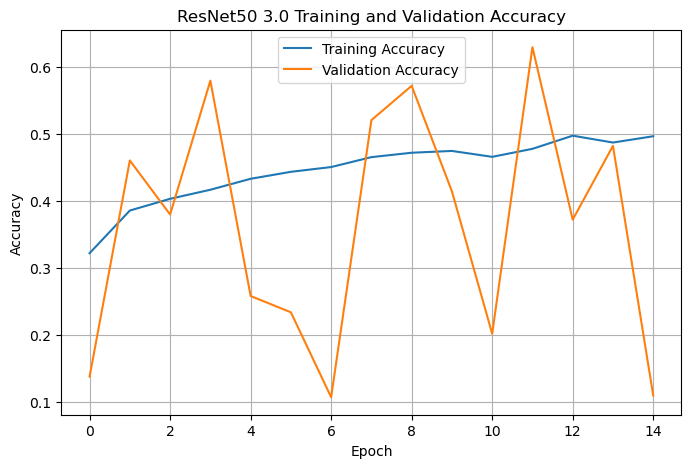

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 3.0 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

save_path = os.path.join(output_dir, "training_validation_accuracy.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("Saved accuracy plot to:", save_path)

plt.show()

Saved loss plot to: resnet50_5class_3_0_results/training_validation_loss.png


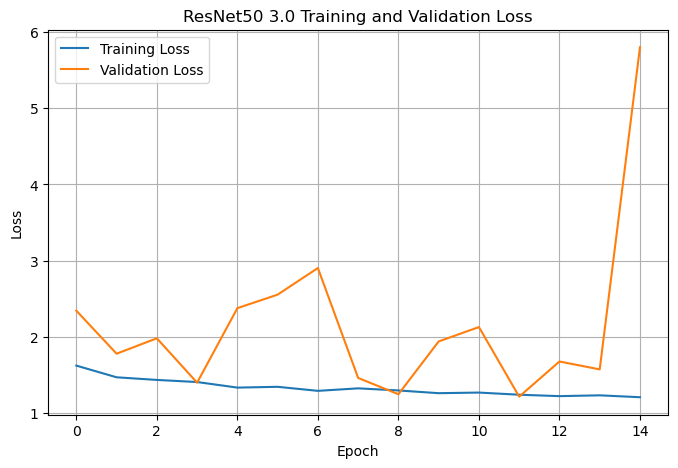

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 3.0 Training and Validation Loss")
plt.legend()
plt.grid(True)

save_path = os.path.join(output_dir, "training_validation_loss.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("Saved loss plot to:", save_path)

plt.show()

Saved confusion matrix plot to: resnet50_5class_3_0_results/confusion_matrix.png


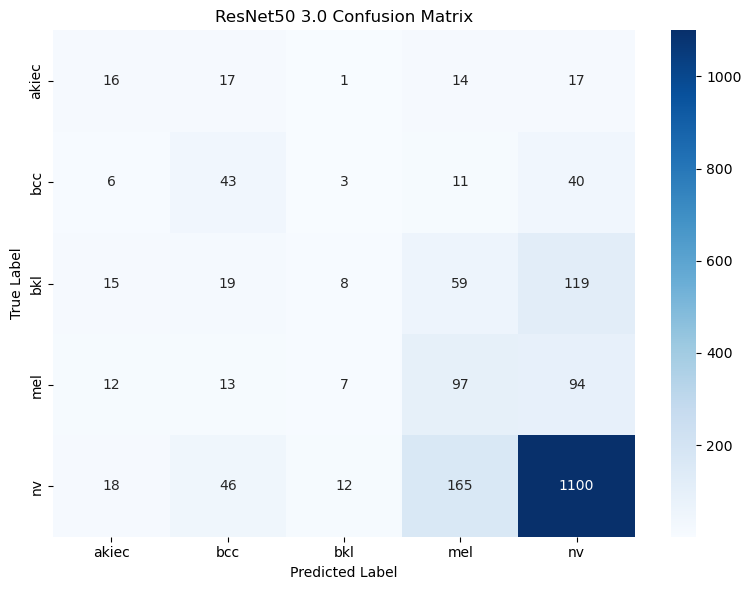

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 3.0 Confusion Matrix")
plt.tight_layout()

save_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("Saved confusion matrix plot to:", save_path)

plt.show()

In [28]:
print("Final files saved in:", output_dir)

for file in os.listdir(output_dir):
    print(file)

Final files saved in: resnet50_5class_3_0_results
training_history.csv
training_summary_metrics.csv
confusion_matrix.csv
classification_report.csv
final_test_metrics.csv
classification_report_from_cm.csv
training_validation_accuracy.png
training_validation_loss.png
confusion_matrix.png
